[[1.  1.4]
 [1.  1. ]
 [1.  1.5]
 [1.  3. ]
 [1.  3.8]
 [1.  4.1]]
[0. 0. 0. 1. 1. 1.]


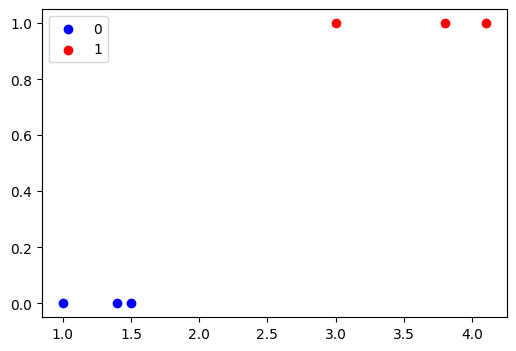

In [3]:
import numpy as np
import matplotlib.pyplot as plt

iris = np.genfromtxt('iris_1D.csv',
                     delimiter=',',
                     skip_header=1)

X = iris[:, :1]
y = iris[:, 1]
N = 6

plt.figure(figsize=(6,4))
plt.scatter(X[y == 0][:, 0], y[y == 0], color='b', label='0')
plt.scatter(X[y == 1][:, 0], y[y == 1], color='r', label='1')
plt.legend()

# intercept = np.ones((X.shape[0], 1))
# X = np.concatenate((intercept, X), axis=1)
X = np.hstack((np.ones((X.shape[0], 1)), X))

print(X)
print(y)

In [4]:
def sigmoid_function(z):
    return 1 / (1 + np.exp(-z))

def loss_function(y_hat, y):
    return (-y * np.log(y_hat) \
            - (1 - y) * np.log(1 - y_hat)).mean()

def predict(X, theta):
    y_hat = sigmoid_function(np.dot(X, theta))
    return y_hat.round()

In [6]:
lr = 0.01
num_iter = 5000

theta = np.array([0.01, -0.01])

losses = []
accs = []

for _ in range(num_iter):
    # compute output
    z = np.dot(X, theta)
    y_hat = sigmoid_function(z)

    # compute loss
    loss = loss_function(y_hat, y)

    # compute mean of gradient
    gradient = np.dot(X.T, (y_hat - y)) / y.size

    # update parameters
    theta -= lr*gradient

    # loss
    losses.append(loss)

    # accuracy
    preds = predict(X, theta)
    acc = (preds == y).mean()
    accs.append(acc)

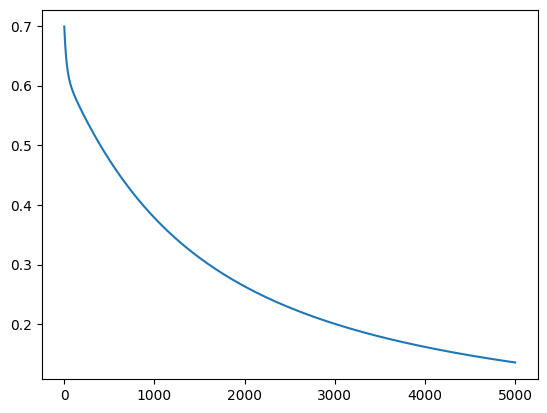

In [8]:
plt.plot(losses)
plt.show()

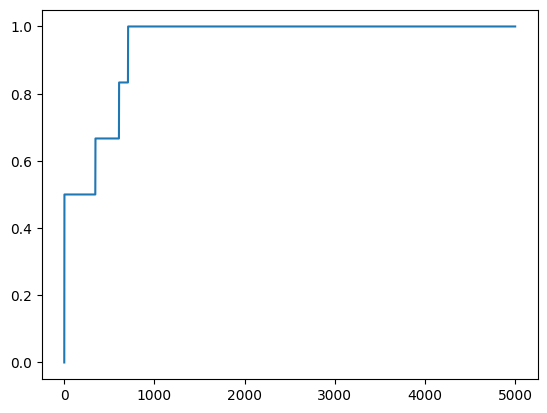

In [9]:
plt.plot(accs)
plt.show()

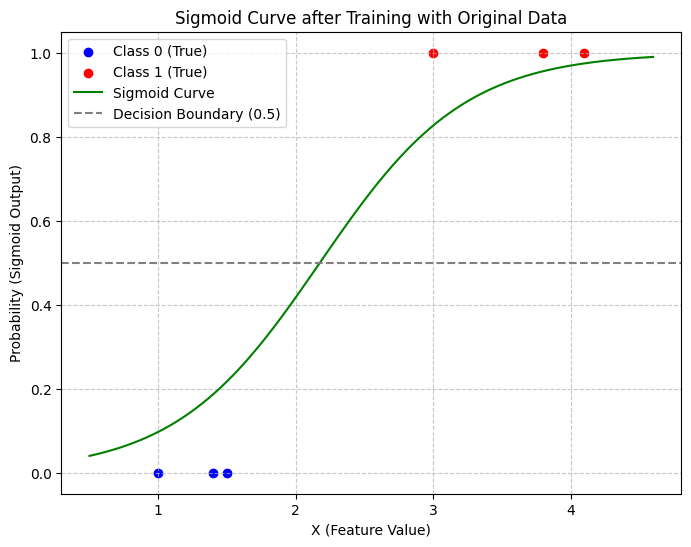

In [11]:
plt.figure(figsize=(8,6))

# Plot original data points
plt.scatter(X[y == 0][:, 1], y[y == 0], color='b', label='Class 0 (True)')
plt.scatter(X[y == 1][:, 1], y[y == 1], color='r', label='Class 1 (True)')

# Generate points for the sigmoid curve
x_min, x_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
x_plot_values = np.linspace(x_min, x_max, 100).reshape(-1, 1)
X_plot_curve = np.hstack((np.ones((x_plot_values.shape[0], 1)), x_plot_values))
y_sigmoid_curve = sigmoid_function(np.dot(X_plot_curve, theta))

# Plot the sigmoid curve
plt.plot(x_plot_values, y_sigmoid_curve, color='green', label='Sigmoid Curve')

plt.title('Sigmoid Curve after Training with Original Data')
plt.xlabel('X (Feature Value)')
plt.ylabel('Probability (Sigmoid Output)')
plt.axhline(0.5, color='gray', linestyle='--', label='Decision Boundary (0.5)') # Add decision boundary
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()